## Regime diagrams

In [1]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from functions import apply_filters
from matplotlib.lines import Line2D

# Use given style and colours
from colors import (
    mixing_c_map,
    label_map,
    author_color,
    marker_style,
)

plt.style.use("james2026lock.mplstyle")

# load experiment table
metadata = pd.read_csv("../../data/metadata/metadata.csv")
compare_data = pd.read_csv("../../data/metadata/literature_comparison.csv")
folder = "../../data/datafiles"

# filter for only particle-laden experiments
part_exp_filt = {"type": "part"}
part_exp = apply_filters(metadata, part_exp_filt).reset_index(drop=True)

# constants
rho_part = 2277
d_part = 22e-6
rho_water = 998.2
visc = 1e-3
h0 = 0.25
h = 0.4 * h0
l0 = 0.27

# state dsm ranges
dsm_re = np.array([20000, 150000])  # reynolds
dsm_phi = np.array([2, 70]) / 2650  # C0/rho_part
dsm_sed = np.array([1e-4, 1e-1])  # sedimentation number
dsm_st = np.array([1e-7, 1e-5])  # sedimentation number

## New regime diagram with data for comparison

- Jacobson & Testik 2014
- Wilson 2017
- Gadal et al. 2023

Experimental variables to compare: $\Phi$, Re, St, $\Sigma$

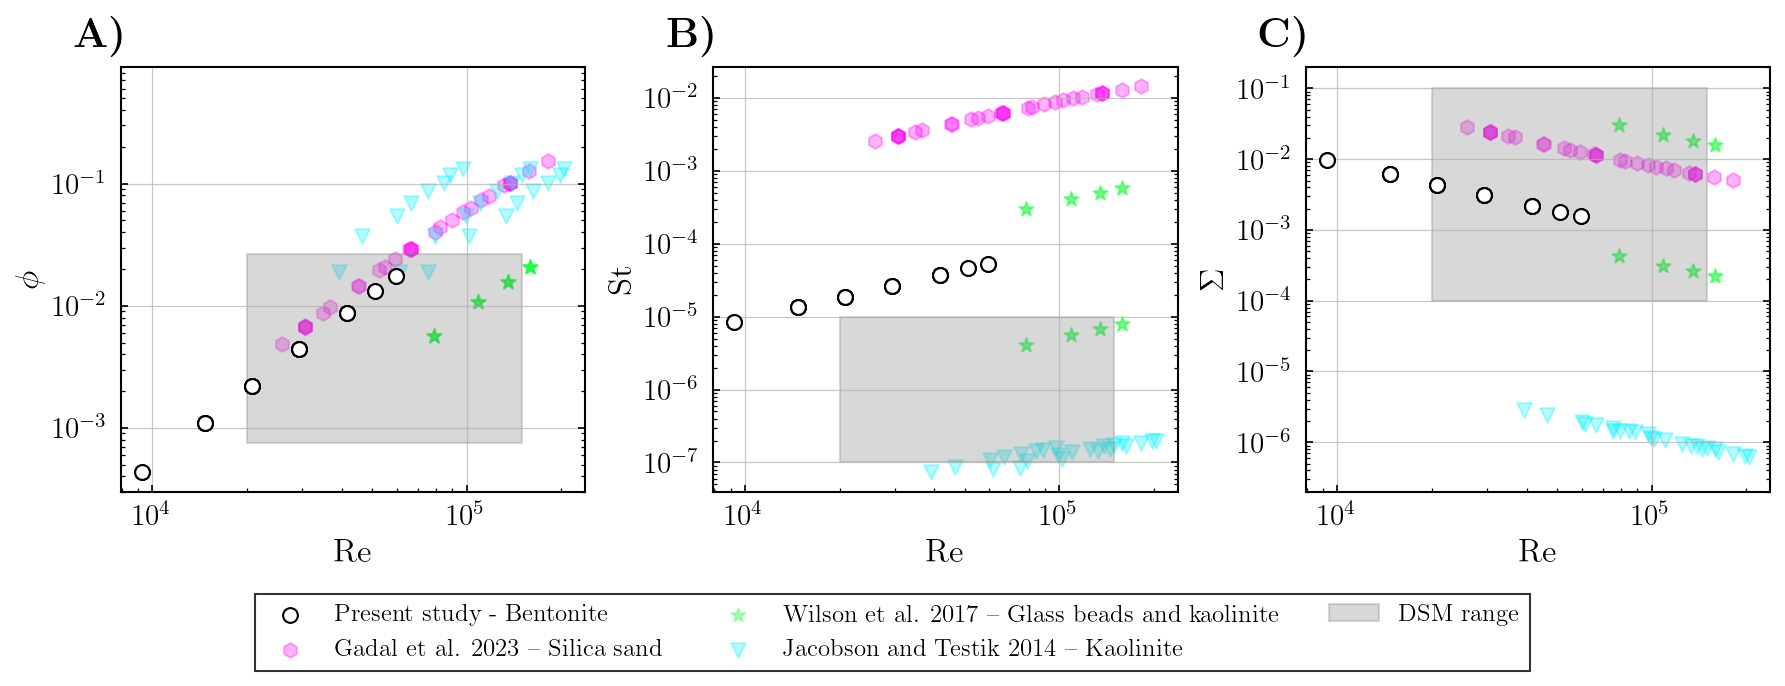

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

# add my data
for row in metadata.itertuples():
    if row.type == "saline":
        continue
    label = "Present study - Bentonite"

    # St & Sed
    tau_p = rho_part * d_part**2 / (18 * visc)
    tau_f = l0 / row.u_0
    vs = vs = (rho_part - rho_water) * d_part**2 * 9.81 / (18 * visc)
    tau_s = h0 / vs

    re = (row.u_0 * 0.25 * row.rho) / visc
    st = tau_p / tau_f
    sed = tau_f / tau_s
    #

    ax[0].scatter(
        re,
        row.C0 / rho_part,
        marker="o",
        edgecolor="k",
        facecolor="w",
        s=50,
        label=label,
        zorder=5,
    )

    ax[2].scatter(
        re,
        sed,
        marker="o",
        edgecolor="k",
        facecolor="w",
        s=50,
        label=label,
        zorder=5,
    )

    ax[1].scatter(
        re,
        st,
        marker="o",
        edgecolor="k",
        facecolor="w",
        s=50,
        label=label,
        zorder=5,
    )


# add comparisons
for row in compare_data.itertuples():
    if row.particle_type == "Saline":
        continue
    author = row.author
    color = author_color[author]
    ptype = row.particle_type
    marker = marker_style[ptype]

    key = (author, ptype)

    # Only assign label the first time this combination appears
    label = f"{author} – {ptype}"

    ax[0].scatter(
        row.Re,
        row.phi,
        label=label,
        color=color,
        marker=marker,
        alpha=0.3,
        s=50,
    )
    ax[2].scatter(
        row.Re,
        row.Sed,
        label=label,
        color=color,
        marker=marker,
        alpha=0.3,
        s=50,
    )

    ax[1].scatter(
        row.Re,
        row.St,
        label=label,
        color=color,
        marker=marker,
        alpha=0.3,
        s=50,
    )

# add coloured boxes for DSM ranges
ax[0].fill_between(
    dsm_re, dsm_phi[0], dsm_phi[1], color="grey", alpha=0.3, label="DSM range"
)
ax[2].fill_between(
    dsm_re, dsm_sed[0], dsm_sed[1], color="grey", alpha=0.3, label="DSM range"
)
ax[1].fill_between(
    dsm_re, dsm_st[0], dsm_st[1], color="grey", alpha=0.3, label="DSM range"
)

ax[0].set_xlabel("Re ")
ax[0].set_ylabel("$\\phi$")
ax[0].set_xscale("log")
ax[0].set_yscale("log")

ax[2].set_xlabel("Re ")
ax[2].set_ylabel("$\\Sigma$")
ax[2].set_xscale("log")
ax[2].set_yscale("log")

ax[1].set_xlabel("Re ")
ax[1].set_ylabel("St ")
ax[1].set_xscale("log")
ax[1].set_yscale("log")

# Create ONE legend for the whole figure
handles0, labels0 = ax[0].get_legend_handles_labels()
handles1, labels1 = ax[2].get_legend_handles_labels()

handles = handles0 + handles1
labels = labels0 + labels1

# remove duplicates while preserving order
unique = dict(zip(labels, handles))
fig.legend(
    unique.values(),
    unique.keys(),
    loc="center",
    bbox_to_anchor=(0.5, -0.07),
    ncols=3,
)

# get xlims
xlim = ax[0].get_xlim()

for axis, label in zip(ax, ["\\textbf{A)}", "\\textbf{B)}", "\\textbf{C)}"]):
    axis.annotate(
        label,
        xy=(-0.1, 1.05),
        xycoords="axes fraction",
        fontsize=20,
        fontweight="bold",
    )

ax[0].set(ylim=(3e-4, 9e-1))
ax[2].set(ylim=(2e-7, 2e-1))

plt.tight_layout()  # leave space for legend
plt.savefig(
    "../figures/figure_5.pdf", format="pdf", bbox_inches="tight", facecolor="white"
)
plt.show()

## Standalone Ri for just my data

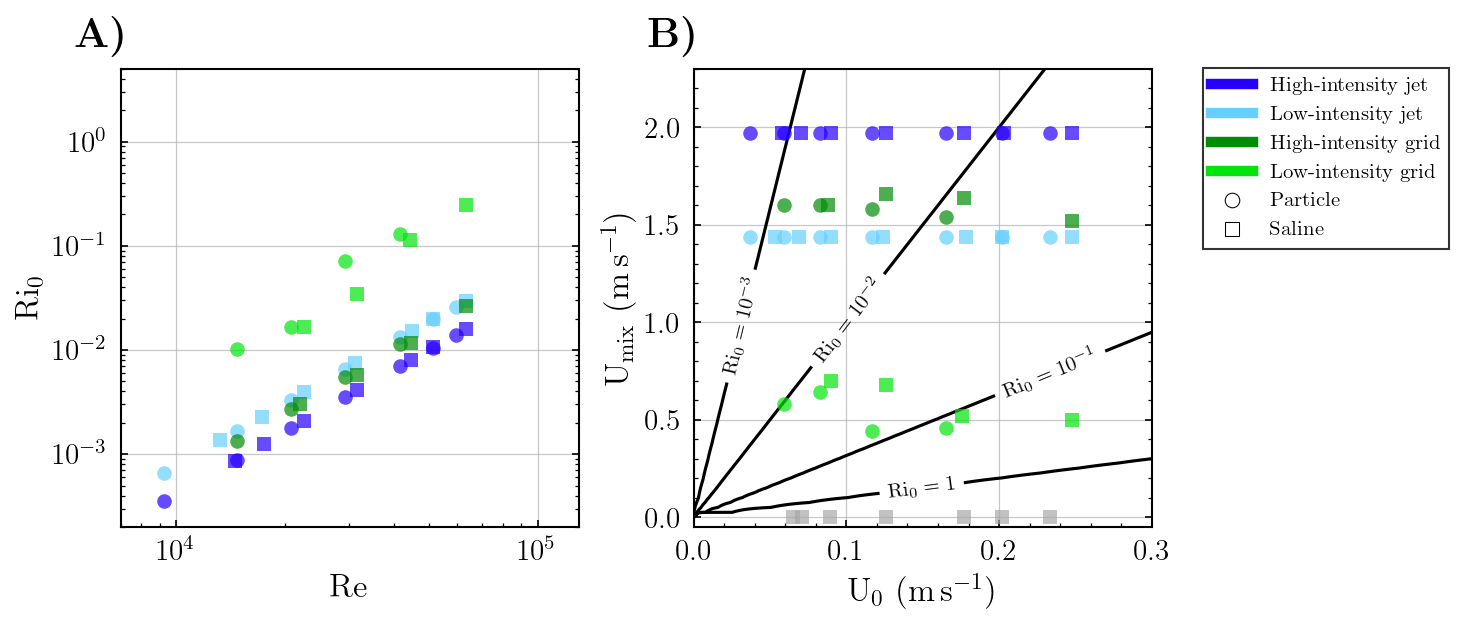

In [ ]:
# --- Ri parameter space grid ---
u0 = np.linspace(0, 0.3, 100)
v_mix = np.linspace(0, 2.5, 100)
U0, V_mix = np.meshgrid(u0, v_mix)
Ri_grid = U0**2 / (V_mix**2 + 1e-6)  # add small epsilon to avoid division by zero

fig, ax = plt.subplots(1, 2, figsize=(8, 4))


# # --- Panel 1: Ri contours in (g', U_mix) space ---
# Overlay Ri isolines
CS = ax[1].contour(U0, V_mix, Ri_grid, levels=np.logspace(-3, 0, 4), colors="k")
# choose positions (x, y) in data coordinates
manual_locations = [(0.15, 0.1), (0.23, 0.8), (0.12, 0.9), (0.02, 1)]


def contour_fmt(x):
    exponent = int(np.log10(x))
    return (
        rf"$\mathrm{{Ri}}_0 = "
        + ("1" if exponent == 0 else rf"10^{{{exponent}}}")
        + "$"
    )


ax[1].clabel(
    CS,
    inline=True,
    fmt=contour_fmt,
    manual=manual_locations,
)


seen = set()  # to track seen mixing types for legend
for _, row in metadata.iterrows():

    # Add label only for the first occurrence of each mixing type
    label = label_map.get(row["mixing"]) if row["mixing"] not in seen else None
    seen.add(row["mixing"])

    # Reduced gravity and Richardson number
    g_prime = 9.81 * row.del_rho / 998.2
    ri = (g_prime * h0) / (row["U_mix"] ** 2)

    # Marker style: circle = particle, square = saline
    c = mixing_c_map.get(row["mixing"])
    m = "o" if row.type == "part" else "s"

    u_mix = row["U_mix"]
    if row.mixing == "none":
        u_mix = 0  # no active mixing for baseline experiments

    re = (row.u_0 * 0.25 * row.rho) / visc

    # Panel 1: experiments overlaid on Ri parameter space
    ax[0].loglog(
        re, ri, marker=m, c=c, markeredgecolor="k", alpha=0.7, markersize=7, label=label
    )

    ax[1].plot(
        row.u_0,
        u_mix,
        marker=m,
        c=c,
        markeredgecolor="k",
        alpha=0.7,
        markersize=7,
        label=label,
    )


ax[0].set(
    xlabel="Re",
    ylabel="Ri$_0$",
    xlim=[7e3, 1.3e5],
    ylim=[2e-4, 5e0],
)

ax[1].set(
    xlabel="U$_0$ (m\\,s$^{-1}$)",
    ylabel="U$_{\\mathrm{mix}}$ (m\\,s$^{-1}$)",
    ylim=[-0.05, 2.3],
    xlim=[0, 0.3],
)
my_legend_elements = [
    *[
        Line2D(
            [0],
            [0],
            color=color,
            linewidth=5,
            label=label_map.get(mixing_type, mixing_type),
        )
        for mixing_type, color in list(mixing_c_map.items())[:-1]
    ],
    # Line2D([0], [0], color="k", linestyle="--", linewidth=1.5, label="Best fit (all)"),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label="Particle",
        markerfacecolor="white",
        markeredgecolor="k",
        markeredgewidth=0.5,
        markersize=7,
    ),
    Line2D(
        [0],
        [0],
        marker="s",
        color="w",
        label="Saline",
        markerfacecolor="white",
        markeredgecolor="k",
        markeredgewidth=0.5,
        markersize=7,
    ),
]


for axis in ax:
    axis.set_box_aspect(1)

fig.legend(
    handles=my_legend_elements,
    bbox_to_anchor=(1, 0.925),
    loc="upper left",
    ncols=1,
    fontsize=10,
)
for axis, label in zip(ax, ["\\textbf{A)}", "\\textbf{B)}"]):
    axis.annotate(
        label,
        xy=(-0.1, 1.05),
        xycoords="axes fraction",
        fontsize=20,
        fontweight="bold",
    )
plt.tight_layout()  # leave space for legend
plt.savefig(
    "../figures/figure_6.pdf", format="pdf", bbox_inches="tight", facecolor="white"
)
plt.show()